In [48]:
# Run this setup only in Google Colab
import os
import subprocess
import sys
    
try:
    from google.colab import drive
    drive.mount("/content/drive")
    os.chdir("/content/drive/MyDrive/Colab Notebooks/ml2_trabalhos_2026")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-r", "requirements.txt"])
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-e", ".", "--no-deps"])
except ModuleNotFoundError:
    print("Not running in Colab; skipping Drive mount and install steps.")

Not running in Colab; skipping Drive mount and install steps.


# Trabalho 1 — Classificação de imagens com o Oxford-IIIT Pet

Neste trabalho, você irá treinar e comparar diferentes modelos para classificação de raças no dataset **Oxford-IIIT Pet**.

**Objetivos.**
- construir um pipeline básico de classificação de imagens;
- comparar arquiteturas simples e profundas;
- investigar o efeito de escolhas de treinamento;
- analisar erros e limitações do modelo.

**Entregáveis.**
1. Este notebook preenchido e executado.
2. Os pesos do melhor modelo;
2. Respostas curtas e objetivas nas células de texto.
3. Tabelas e gráficos pedidos ao longo do trabalho.

**Regras gerais.**
- Use **PyTorch**.
- Registre as escolhas principais de hiperparâmetros.
- Quando o enunciado pedir comparação, use evidências dos seus resultados.
- Não apague as células do enunciado.
- Use o conjunto de **teste** apenas na etapa final.



## Parte 0 — Setup e reprodutibilidade

Como treinamos algoritmos que possuem escolhas randômicas, e em máquinas com configurações possivelmente distintas. É importante tentar controlar essas variáveis para garantirmos o máximo de reprodutibilidade dos nossos experimentos.

**Tarefa 0.1**  
Fixe as seeds aleatórias e configure o dispositivo (`cpu` ou `cuda`).

**Tarefa 0.2**  
Imprima as versões de `torch` e `torchvision`, e indique se o notebook está usando CPU ou GPU.

**Tarefa 0.3**  
Crie uma variável `student_run_tag` com uma string curta de sua escolha (por exemplo, suas iniciais e a data).  
Use essa tag ao salvar modelos, figuras e demais artefatos produzidos no notebook.



In [49]:
# TODO: importe as bibliotecas principais
import random
import numpy as np
from pathlib import Path

import torch
import torchvision

# Sugestão: complete com torch.nn, torch.optim, matplotlib etc.
import torch.nn as nn
import torch.optim as optim

import matplotlib.pyplot as plt

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
# Adição de generator com a seed setada:
generator = torch.Generator().manual_seed(seed)

# torch.backend.cudnn.deterministic = True
# torch.backend.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Semente: {seed}")
print(f"Dispositivo: {device}")
print("Versão do Torch:", torch.__version__)
print("Versão do Torchvision:", torchvision.__version__)

student_run_tag = "tainaqd"
output_dir = Path("assignment1_outputs")
output_dir.mkdir(exist_ok=True)
(output_dir / student_run_tag).mkdir(exist_ok=True)
print("Diretório de saída:", output_dir / student_run_tag)

Semente: 42
Dispositivo: cuda
Versão do Torch: 2.11.0+cu126
Versão do Torchvision: 0.26.0+cu126
Diretório de saída: assignment1_outputs/tainaqd


## 1. Carregar dados e fazer split

Use o dataset **Oxford-IIIT Pet** do `torchvision`.

**Tarefas**
1. Baixe/carregue o dataset.
2. Separe os dados em **treino**, **validação** e **teste**.
3. Explique brevemente qual split você usou.
4. Mostre o número de exemplos em cada parte.

**Observação.**
- Você pode usar o split oficial de treino/teste e separar parte do treino para validação.
- Para a maior parte do trabalho, use inicialmente transformações simples.


In [50]:
# TODO:
# - importar OxfordIIITPet
# - definir transformações iniciais
# - carregar conjuntos
# - criar split treino/validação
# - criar DataLoaders

# Estrutura sugerida:
from torchvision.datasets import OxfordIIITPet
from torchvision import transforms
from torch.utils.data import DataLoader, random_split

image_size = 224
batch_size = 64

# Escreva seu código aqui
transform = transforms.ToTensor()

In [51]:
# Download do dataset separado para treino/validação e teste
trainval_dataset = OxfordIIITPet(root="./data", split="trainval", transform=transform, download=True)
test_dataset = OxfordIIITPet(root="./data", split="test", transform=transform, download=True)

In [52]:
# Separação de treino e validação
val_size = int(0.2 * len(trainval_dataset))
train_size = len(trainval_dataset) - val_size

train_dataset, val_dataset = random_split(trainval_dataset, [train_size, val_size], generator=generator)

In [53]:
# Criação dos DataLoaders
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(dataset=val_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

### Resposta 1.3

Explique brevemente como você construiu o split de treino, validação e teste.


Inicialmente, utilizei o split padrão do dataset para separar em treino e teste. 
Depois, dividi o dataset de treino em 80% para treino e 20% para validação usando a função random_split. Para reprodutibilide dos resultados, utilizei o generator com a seed configurada no começo deste notebook.

Por fim, com cada um dos datasets devidamente separados, construí os DataLoaders com o batch_size=64.

## 2. Visualizar dados e inspecionar balanceamento

Antes de treinar, inspecione o dataset.

**Tarefas**
1. Mostre algumas imagens com seus rótulos.
2. Conte quantos exemplos há por classe no conjunto de treino.
3. Faça um gráfico simples da distribuição por classe.
4. Comente se o conjunto parece balanceado ou não.
5. Aponte ao menos uma dificuldade visual do problema.

In [54]:
# TODO:
# - mostrar algumas imagens do treino
# - obter nomes/classes
# - contar frequência por classe
# - fazer um gráfico simples

# Escreva seu código aqui
# Análise do formato dos dados
breed_names = train_dataset.dataset.classes
print(f"Número de classes: {len(breed_names)}")

print("Dez primeiros dados de treino:")
print(f"img format | breed id | breed name")
for i in range(10):
    image, label = train_dataset[i]
    print(image.shape, label, breed_names[label])


Número de classes: 37
Dez primeiros dados de treino:
img format | breed id | breed name
torch.Size([3, 375, 500]) 19 Leonberger
torch.Size([3, 352, 400]) 0 Abyssinian
torch.Size([3, 500, 375]) 14 German Shorthaired
torch.Size([3, 375, 500]) 27 Russian Blue
torch.Size([3, 375, 500]) 4 Beagle
torch.Size([3, 334, 500]) 19 Leonberger
torch.Size([3, 500, 388]) 19 Leonberger
torch.Size([3, 352, 500]) 19 Leonberger
torch.Size([3, 500, 375]) 17 Japanese Chin
torch.Size([3, 333, 500]) 26 Ragdoll


Imagens dos dez primeiros dados de treino:


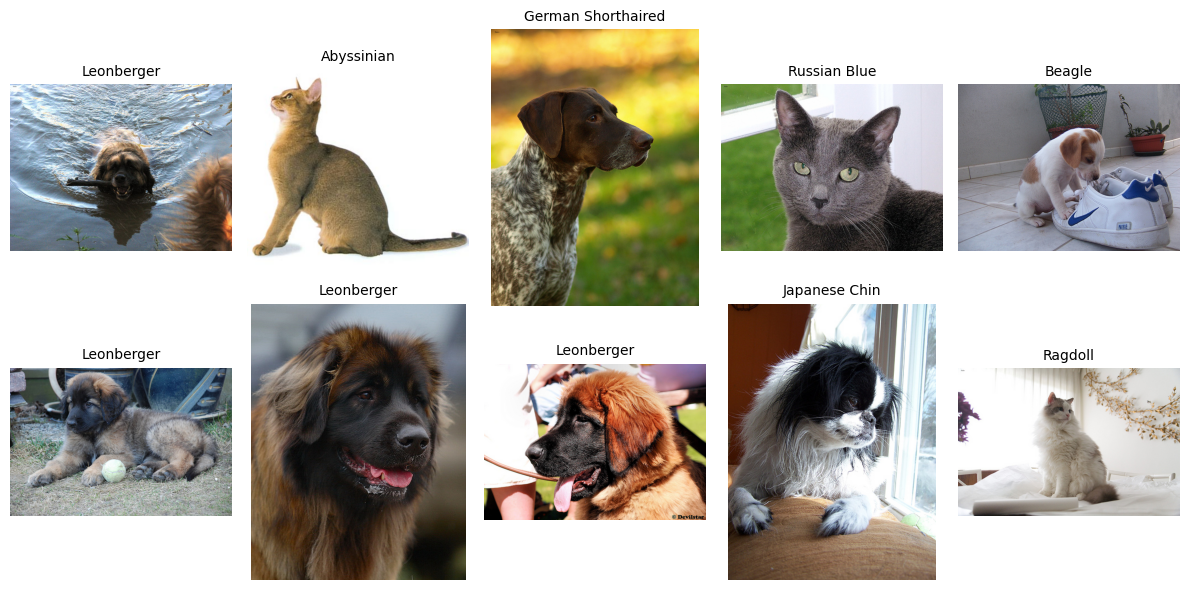

In [55]:
# Visualização de imagens
print("Imagens dos dez primeiros dados de treino:")

fig = plt.figure(figsize=(12, 6))
for i in range(10):
    ax = fig.add_subplot(2, 5, i+1)
    image, label = train_dataset[i]
    ax.imshow(image.permute(1, 2, 0))
    ax.set_title(breed_names[label], fontsize=10)
    ax.axis("off")
plt.tight_layout()
plt.show()

In [56]:
# Distribuição das classes em treino
labels = np.array([train_dataset[i][1] for i in range(len(train_dataset))])
unique, counts = np.unique(labels, return_counts=True)

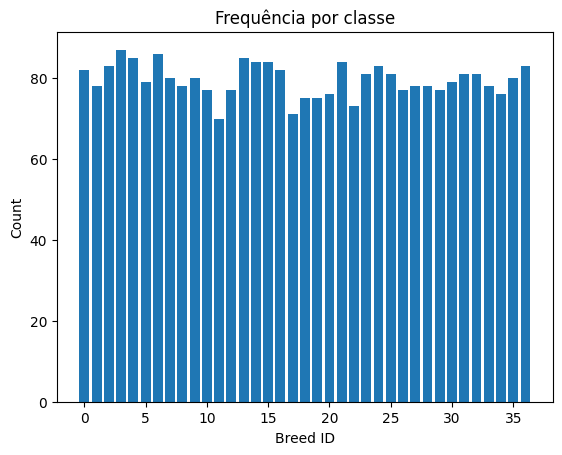

In [57]:
plt.bar(unique, counts)
plt.xlabel("Breed ID")
plt.ylabel("Count")
plt.title("Frequência por classe")
plt.show()

Como as imagens têm dimensões diferentes, precisamos redimensioná-las para um padrão comum.

In [58]:
transform_resize = transforms.Compose([
                    transforms.Resize((224, 224)),
                    transforms.ToTensor()
                ])

trainval_dataset = OxfordIIITPet(root="./data", split="trainval", transform=transform_resize, download=True)
test_dataset = OxfordIIITPet(root="./data", split="test", transform=transform_resize, download=True)

val_size = int(0.2 * len(trainval_dataset))
train_size = len(trainval_dataset) - val_size

train_dataset, val_dataset = random_split(trainval_dataset, [train_size, val_size], generator=generator)

train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(dataset=val_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

### Resposta 2.4–2.5

Com base nas visualizações e na distribuição por classe, descreva brevemente o que você observou.


Identifiquei que há 37 classes distintas nesse dataset. Explorando a pasta annotations dos dados, identifiquei que essas classes correspondem a raças de gato e cachorro.

Os labels são numéricos e as imagens do dataset têm dimensões espaciais diferentes (tanto em altura quanto em largura). Todas elas possuem 3 features (RGB).

Como as redes esperam dados de dimensões fixas, eu redimensionei as imagens para todas ficarem no padrão 224x224 e redefini os DataLoaders com essa alteração.

Quanto à distribuição dos dados por classe, o dataset parece estar bem balanceado. No histograma de frequência por classe no dataset de treino, é possível notar que cada classe possui cerca de 80 observações.

## 3. Construa uma FNN simples

Agora construa um primeiro modelo totalmente conectado (**FNN**).

**Tarefas**
1. Defina uma arquitetura simples em PyTorch.
2. Sua FNN deve receber a imagem achatada.
3. Escolha dimensões ocultas razoáveis.
4. Informe o número de parâmetros do modelo.

**Observação.**
Este modelo serve como baseline simples. Não é esperado que funcione bem.


In [59]:
# TODO:
# - definir uma classe FNN(nn.Module)
# - achatar a entrada
# - retornar logits para o número de classes
# - criar uma instância do modelo

# Dica:
# class SimpleFNN(nn.Module):
#     ...

# Escreva seu código aqui
class SimpleFNN(nn.Module):
    def __init__(self):
        super().__init__()
        
        layer_sizes = [3*224*224, 512, 256, 128, 37]
        layers = []
        
        for i in range(len(layer_sizes) - 1):
            layers.append(
                nn.Linear(layer_sizes[i], layer_sizes[i+1])
            )
            if i != len(layer_sizes) - 2:
                layers.append(nn.ReLU())
                
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        out = x.reshape(x.size(0), -1)
        out = self.network(out)
            
        return out

TODO: NÚMERO DE PARÂMETROS DO MODELO

## 4. Crie funções de treino e avaliação

Implemente funções reutilizáveis para os próximos experimentos.

**Tarefas**
1. Crie uma função `train_one_epoch`.
2. Crie uma função `evaluate`.
3. Crie uma função `fit` que registre métricas por época.
4. Sua avaliação deve retornar pelo menos:
   - loss média
   - acurácia

**Importante.**
Essas funções serão reutilizadas em várias partes do trabalho.


### Resposta 4.1

In [60]:
# TODO:
# - implementar train_one_epoch
# - implementar evaluate
# - implementar fit
# - opcional: salvar histórico em dicionário

# Assinaturas sugeridas:
# def train_one_epoch(model, loader, optimizer, criterion, device):
#     ...
#
# @torch.no_grad()
# def evaluate(model, loader, criterion, device):
#     ...
#
# def fit(model, train_loader, val_loader, optimizer, criterion, device, epochs, scheduler=None):
#     ...

# Escreva seu código aqui

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    
    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)
        
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

### Resposta 4.2

In [61]:
@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    correct = 0
    total = 0
    running_loss = 0.0
    
    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)
        
        outputs = model(images)
        
        loss = criterion(outputs, labels)
        running_loss += loss.item()

        total += labels.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        
    loss = running_loss / len(loader)
    accuracy = 100 * correct / total

    return loss, accuracy

### Resposta 4.3

In [62]:
def plot_evaluation(epochs, model_hist):
    train_loss_hist, train_accuracy_hist, val_loss_hist, val_accuracy_hist = model_hist

    epoch_range = range(1, epochs + 1)
    
    _, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    ax1.plot(epoch_range, train_loss_hist, label="Train Loss", color="blue", lw=2)
    ax1.plot(epoch_range, val_loss_hist, label="Validation Loss", color="orange", lw=2)
    ax1.set_title("Loss vs. Epochs", fontsize=14, pad=15)
    ax1.set_xlabel("Epoch", fontsize=12)
    ax1.set_ylabel("Loss", fontsize=12)
    ax1.legend()
    ax1.grid(True, linestyle=':', alpha=0.6)

    ax2.plot(epoch_range, train_accuracy_hist, label="Train Acc", color="blue", lw=2)
    ax2.plot(epoch_range, val_accuracy_hist, label="Validation Acc", color="orange", lw=2)
    ax2.set_title("Accuracy vs. Epochs", fontsize=14, pad=15)
    ax2.set_xlabel("Epoch", fontsize=12)
    ax2.set_ylabel("Accuracy (%)", fontsize=12)
    ax2.legend()
    ax2.grid(True, linestyle=':', alpha=0.6)

    plt.tight_layout()
    plt.show()
    
def fit(model, train_loader, val_loader, optimizer, criterion, device, epochs, scheduler=None):
    train_loss_hist = []
    val_loss_hist = []
    train_accuracy_hist = []
    val_accuracy_hist = []
    
    for i in range(epochs):
        train_one_epoch(model, train_loader, optimizer, criterion, device)
        
        train_loss, train_accuracy = evaluate(model, train_loader, criterion, device)
        train_loss_hist.append(train_loss)
        train_accuracy_hist.append(train_accuracy)

        val_loss, val_accuracy = evaluate(model, val_loader, criterion, device)
        val_loss_hist.append(val_loss)
        val_accuracy_hist.append(val_accuracy)
        
        print(f"{i+1}/{epochs} --- loss: {train_loss} | acc treino: {train_accuracy} | acc val: {val_accuracy}")
    
    return (train_loss_hist, train_accuracy_hist, val_loss_hist, val_accuracy_hist)

## 5. Treine e avalie a FNN

Use as funções anteriores para treinar sua FNN.

**Tarefas**
1. Escolha uma loss apropriada.
2. Escolha um otimizador.
3. Treine por algumas épocas.
4. Mostre curvas de treino/validação.
5. Reporte as métricas finais em validação.
6. Faça um comentário curto sobre o desempenho da FNN.

**Sugestão.**
Registre as escolhas de hiperparâmetros em uma célula ou tabela.


In [63]:
# TODO:
# - definir criterion e optimizer
# - treinar a FNN
# - guardar histórico
# - plotar curvas
# - reportar métricas finais

# Escreva seu código aqui

simpleFNN = SimpleFNN().to(device)

### Resposta 5.1: Escolha da loss

In [64]:
cross_entropy = nn.CrossEntropyLoss()

### Resposta 5.2: Escolha do otimizador

In [65]:
optim_simpleFNN = optim.Adam(simpleFNN.parameters())

### Resposta 5.3: Treino da FNN simples

In [66]:
epochs = 50
simpleFNN_hist = fit(simpleFNN, train_loader, val_loader, optim_simpleFNN, cross_entropy, device, epochs)

KeyboardInterrupt: 

### Resposta 5.4: Curvas de treino/validação

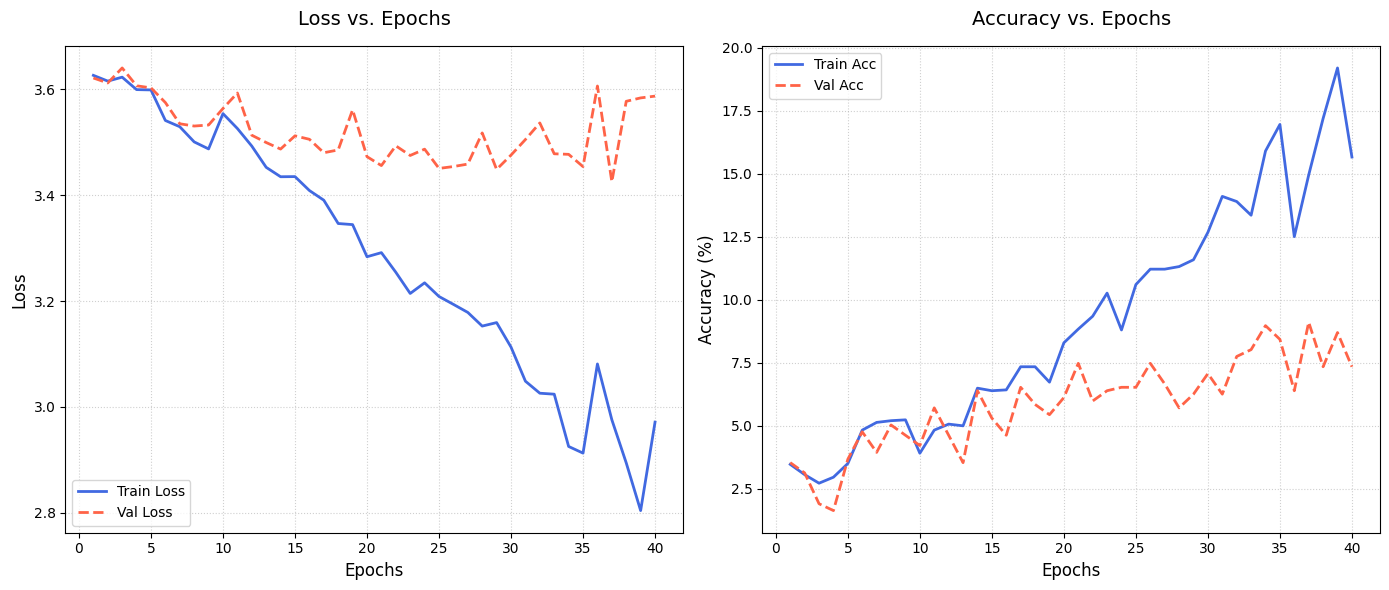

In [ ]:
plot_evaluation(epochs, simpleFNN_hist)

### Resposta 5.5: Métricas finais em validação

In [ ]:
val_loss, val_accuracy = evaluate(simpleFNN, val_loader, cross_entropy, device)
print(f"Validation loss: {val_loss:.4f} | Validation accuracy: {val_accuracy:.4f}")

7.79503952030526


### Resposta 5.6: Comentando o desempenho da FNN

Comente brevemente o desempenho da FNN. Ela parece adequada para esse problema? Por quê?


## 6. Construa uma CNN simples e compare com a FNN

Agora implemente uma CNN simples.

**Tarefas**
1. Defina uma CNN com algumas camadas convolucionais.
2. Treine e avalie a CNN usando o mesmo protocolo da FNN.
3. Compare FNN e CNN em termos de:
   - acurácia;
   - comportamento das curvas;
   - número de parâmetros.

**Observação.**
A comparação deve ser baseada nos seus resultados.


### Resposta 6.1: Definição da arquitetura da CNN simples

In [ ]:
# TODO:
# - definir uma CNN simples
# - treinar
# - avaliar
# - comparar com a FNN

# Dica:
# class SimpleCNN(nn.Module):
#     ...

# Escreva seu código aqui

class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            
            nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(in_channels=256, out_channels=512, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
        )

        self.flatten = nn.Flatten()

        self.fc = nn.Sequential(
            nn.Linear(4608, 512),
            nn.ReLU(),

            nn.Linear(512, 37)
        )
    
    def forward(self, x):
        out = self.conv(x)
        out = self.flatten(out)
        out = self.fc(out)
        
        return out


### Resposta 6.2: Treino da CNN simples

In [ ]:
simpleCNN = SimpleCNN().to(device)
optim_simpleCNN = optim.Adam(simpleCNN.parameters())

In [ ]:
epochs = 50

simpleCNN_hist = fit(simpleCNN, train_loader, val_loader, optim_simpleCNN, cross_entropy, device, epochs)

1/30 --- loss: 3.6111713544182154 | acc treino: 2.751358695652174 | acc val: 2.5815217391304346
2/30 --- loss: 3.607539871464605 | acc treino: 3.3627717391304346 | acc val: 2.5815217391304346
3/30 --- loss: 3.476511219273443 | acc treino: 6.351902173913044 | acc val: 4.076086956521739
4/30 --- loss: 3.3791037020475967 | acc treino: 8.016304347826088 | acc val: 7.065217391304348
5/30 --- loss: 3.261606864307238 | acc treino: 11.514945652173912 | acc val: 8.28804347826087
6/30 --- loss: 3.126519659291143 | acc treino: 14.028532608695652 | acc val: 9.375
7/30 --- loss: 2.95415897473045 | acc treino: 18.682065217391305 | acc val: 9.103260869565217
8/30 --- loss: 2.7897035246310025 | acc treino: 23.94701086956522 | acc val: 9.375
9/30 --- loss: 2.484181414479795 | acc treino: 29.585597826086957 | acc val: 11.956521739130435
10/30 --- loss: 2.3192899849103843 | acc treino: 33.389945652173914 | acc val: 11.277173913043478
11/30 --- loss: 2.101661985335143 | acc treino: 39.84375 | acc val: 12.

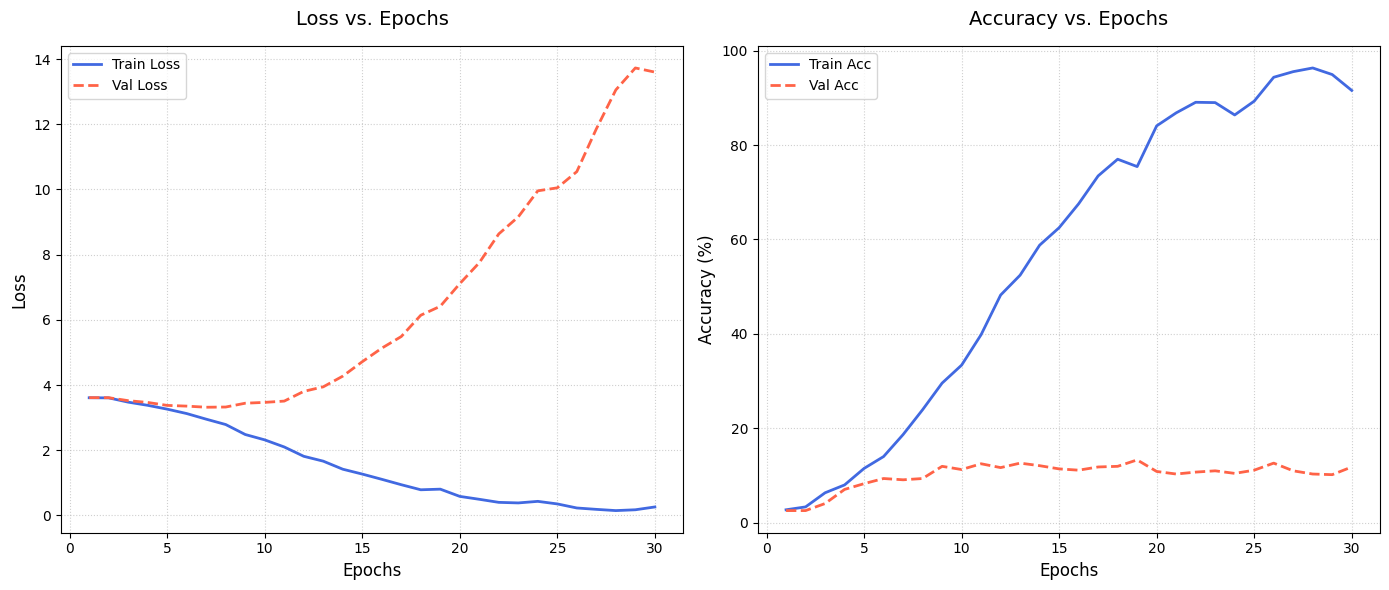

In [ ]:
plot_evaluation(epochs, simpleCNN_hist)

In [ ]:
val_loss, val_accuracy = evaluate(simpleCNN, val_loader, cross_entropy, device)
print(f"Validation loss: {val_loss:.4f} | Validation accuracy: {val_accuracy:.4f}")

10.357045516489507


### Resposta 6.3: Comparação entre FNN e CNN simples

Compare FNN e CNN de forma objetiva. O que mudou? O resultado era esperado?


## 7. Faça pelo menos 3 modificações no treinamento

A partir da sua CNN simples, escolha **pelo menos 3** modificações da lista abaixo:

- Dara Augmentation;
- outro otimizador;
- learning rate scheduler;
- batch normalization;
- dropout;
- CNN mais profunda;
- weight decay regularizer.

**Tarefas**
1. Escolha no mínimo 3 modificações.
2. Execute experimentos controlados.
3. Organize os resultados em uma tabela.
4. Indique claramente qual configuração foi a melhor.

**Importante.**
Tente mudar uma coisa por vez sempre que possível.


### Resposta 7.1: Adição de modificação à CNN simples

In [ ]:
# TODO:
# - definir ao menos 3 experimentos
# - treinar cada configuração
# - registrar resultados em uma tabela final


TODO: REMOVER

ideia de desenvolvimento:

antes de tudo: alterar a arquitetura da CNN simples para ficar mais parecida com a da VGG, para que o salto no passo 5 (descrito a seguir) não seja muito grande

1) adição de batch normalization para melhorar a questão do overfitting e a estabilidade do treinamento
2) dropout para diminuir overfitting
3) data augmentation para lidar com o tamanho limitado do dataset de treino e também com o overfitting
4) overfiting ainda não melhorou: usar global average pooling
5) aumentar a profundidade da rede com global average pooling

#### Batch Normalization

In [67]:
class ModifiedCNN(nn.Module):
    def __init__(self, dropout=False):
        super().__init__()

        self.conv = nn.Sequential(
            nn.BatchNorm2d(3),

            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            
            nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(in_channels=256, out_channels=512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
        )

        self.flatten = nn.Flatten()

        self.fc = nn.Sequential(
            nn.Linear(4608, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),

            nn.Dropout(p=0.5) if dropout else nn.Identity(512),
            nn.Linear(512, 37)
        )
    
    def forward(self, x):
        out = self.conv(x)
        out = self.flatten(out)
        out = self.fc(out)
        
        return out

In [68]:
modifiedCNN1 = ModifiedCNN().to(device)
optim_modifiedCNN1 = optim.Adam(modifiedCNN1.parameters())

In [69]:
epochs = 50

modifiedCNN1_hist = fit(modifiedCNN1, train_loader, val_loader, optim_modifiedCNN1, cross_entropy, device, epochs)

1/50 --- loss: 3.3022577969924263 | acc treino: 11.85461956521739 | acc val: 7.065217391304348


KeyboardInterrupt: 

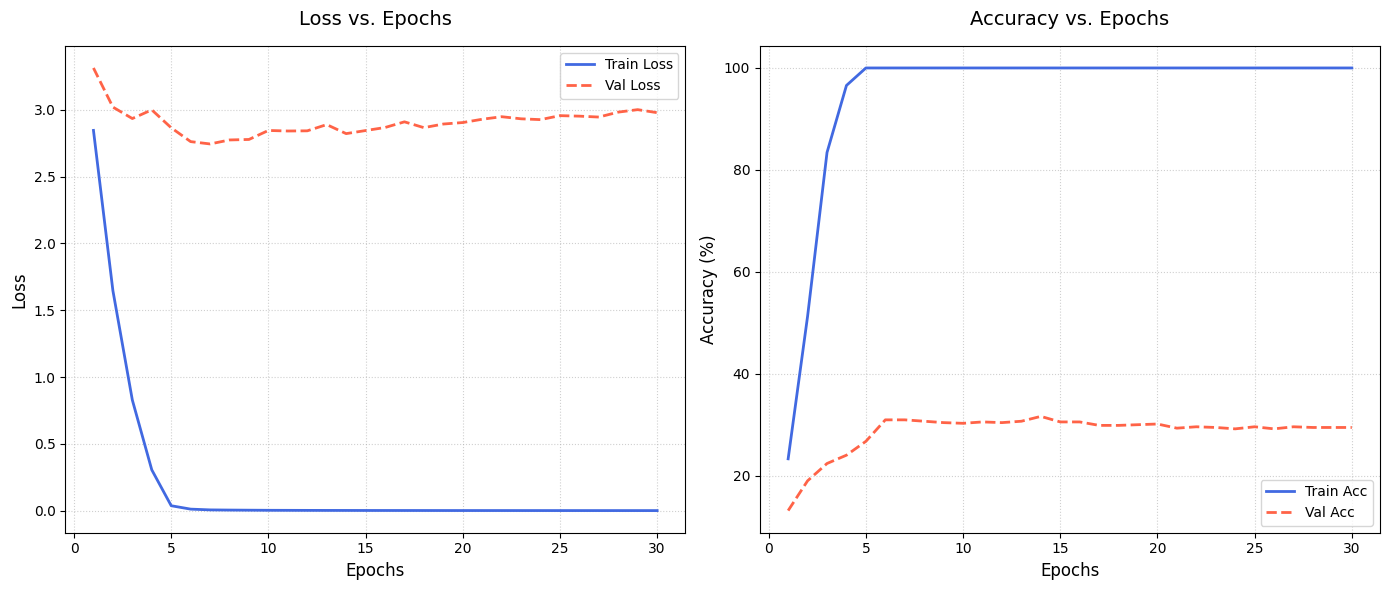

In [ ]:
plot_evaluation(epochs, modifiedCNN1_hist)

#### Dropout

In [ ]:
modifiedCNN2 = ModifiedCNN(dropout=True).to(device)
optim_modifiedCNN2 = optim.Adam(modifiedCNN2.parameters())

In [ ]:
epochs = 50

modifiedCNN2_hist = fit(modifiedCNN2, train_loader, val_loader, optim_modifiedCNN2, cross_entropy, device, epochs)

1/30 --- loss: 2.7727811699328213 | acc treino: 22.860054347826086 | acc val: 15.353260869565217
2/30 --- loss: 2.154042127339736 | acc treino: 41.16847826086956 | acc val: 17.66304347826087
3/30 --- loss: 1.6221802804781043 | acc treino: 53.73641304347826 | acc val: 22.690217391304348
4/30 --- loss: 0.9269759020079738 | acc treino: 84.10326086956522 | acc val: 24.184782608695652
5/30 --- loss: 0.63218060394992 | acc treino: 88.62092391304348 | acc val: 21.331521739130434
6/30 --- loss: 0.20285878460044446 | acc treino: 98.60733695652173 | acc val: 24.456521739130434
7/30 --- loss: 0.04732131115768267 | acc treino: 100.0 | acc val: 26.222826086956523
8/30 --- loss: 0.02388035461468541 | acc treino: 100.0 | acc val: 26.766304347826086
9/30 --- loss: 0.010855774415413971 | acc treino: 100.0 | acc val: 29.07608695652174
10/30 --- loss: 0.006985855673480293 | acc treino: 100.0 | acc val: 28.940217391304348
11/30 --- loss: 0.0046011024691245475 | acc treino: 100.0 | acc val: 29.483695652173

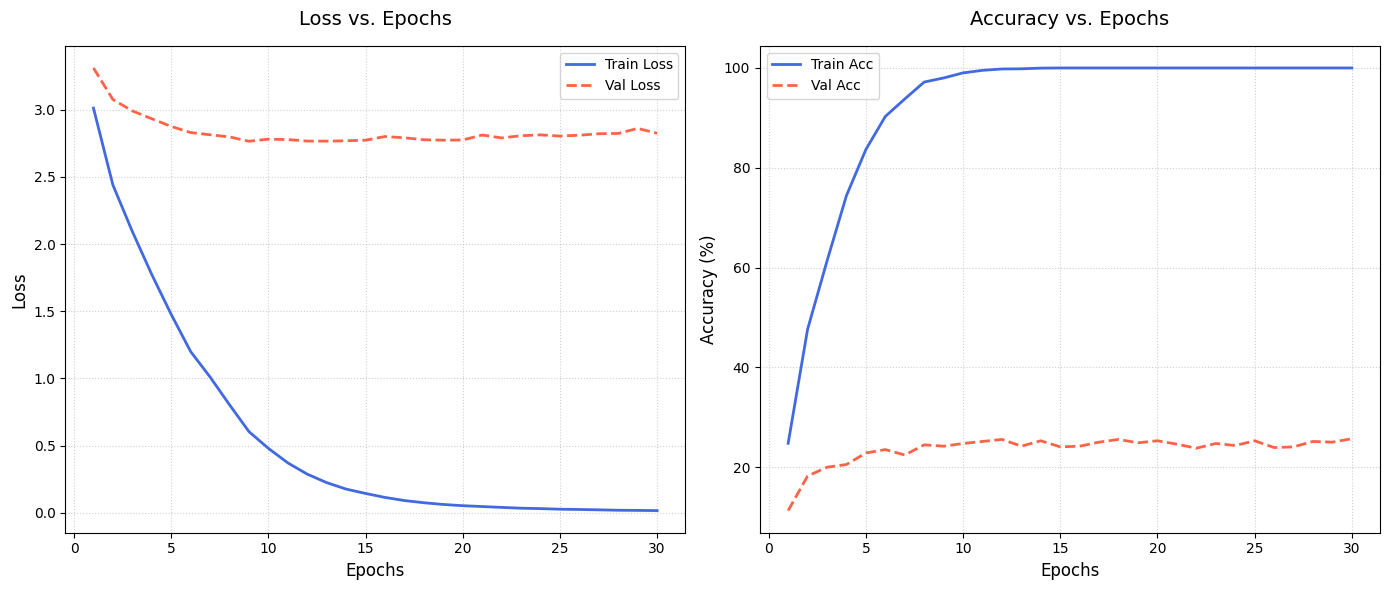

In [ ]:
plot_evaluation(epochs, modifiedCNN2_hist)

#### Data augmentation

In [70]:
class ApplyImageTransform(torch.utils.data.Dataset):
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform

    def __getitem__(self, index):
        image, label = self.subset[index]
        image = self.transform(image)
        return image, label

    def __len__(self):
        return len(self.subset) 

In [ ]:
img_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(30),
    transforms.RandomResizedCrop(size=224, scale=(0.08, 1.0)),
    transforms.ColorJitter(brightness=0.2),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.2)
])

augmented_train_dataset = ApplyImageTransform(train_dataset, transform=img_transforms)
augmented_train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)

In [ ]:
modifiedCNN3 = ModifiedCNN(dropout=True).to(device)
optim_modifiedCNN3 = optim.Adam(modifiedCNN3.parameters())

In [ ]:
epochs = 50

modifiedCNN3_hist = fit(modifiedCNN3, augmented_train_loader, val_loader, optim_modifiedCNN3, cross_entropy, device, epochs)

1/50 --- loss: 2.7891284590182095 | acc treino: 23.335597826086957 | acc val: 13.043478260869565
2/50 --- loss: 2.0005582674689917 | acc treino: 47.82608695652174 | acc val: 23.369565217391305
3/50 --- loss: 1.3728724562603494 | acc treino: 68.91983695652173 | acc val: 21.875
4/50 --- loss: 1.0113363719504813 | acc treino: 75.16983695652173 | acc val: 18.342391304347824
5/50 --- loss: 0.7142022271519122 | acc treino: 82.03125 | acc val: 16.168478260869566
6/50 --- loss: 0.1417578847511955 | acc treino: 99.7961956521739 | acc val: 23.91304347826087
7/50 --- loss: 0.06064977707422298 | acc treino: 99.96603260869566 | acc val: 22.554347826086957
8/50 --- loss: 0.02250076364725828 | acc treino: 100.0 | acc val: 23.777173913043477
9/50 --- loss: 0.010814445214750975 | acc treino: 100.0 | acc val: 25.27173913043478
10/50 --- loss: 0.006148114992791544 | acc treino: 100.0 | acc val: 25.679347826086957
11/50 --- loss: 0.0036780151700519996 | acc treino: 100.0 | acc val: 27.17391304347826
12/50

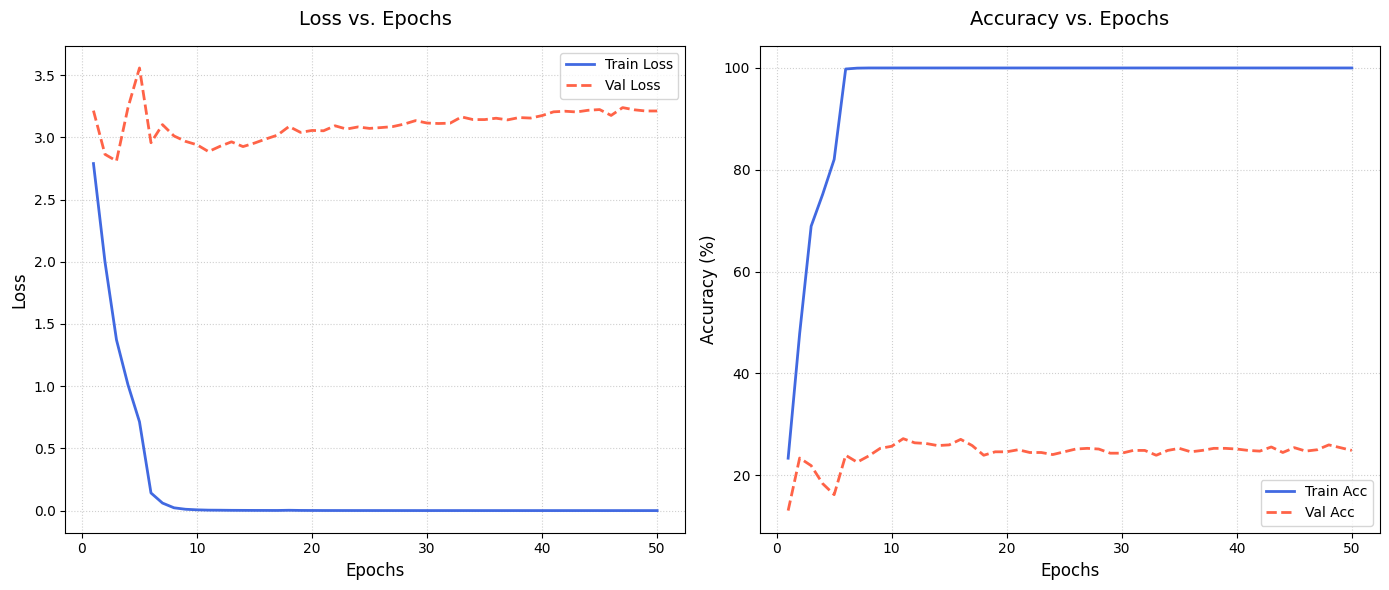

In [ ]:
plot_evaluation(epochs, modifiedCNN3_hist)

#### Reduced learning rate

In [72]:
modifiedCNN4 = ModifiedCNN(dropout=True).to(device)
optim_modifiedCNN4 = optim.Adam(modifiedCNN4.parameters(), lr=1e-4)

In [ ]:
epochs = 50

modifiedCNN4_hist = fit(modifiedCNN4, augmented_train_loader, val_loader, optim_modifiedCNN4, cross_entropy, device, epochs)

In [ ]:
plot_evaluation(epochs, modifiedCNN4_hist)

#### Global average pooling

In [75]:
class GAP_CNN(nn.Module):
    def __init__(self, dropout=False):
        super().__init__()

        self.conv = nn.Sequential(
            nn.BatchNorm2d(3),

            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            
            nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(in_channels=256, out_channels=512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.AdaptiveAvgPool2d((1, 1)),
        )

        self.flatten = nn.Flatten()

        self.fc = nn.Sequential(
            nn.Linear(512, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),

            nn.Dropout(p=0.5) if dropout else nn.Identity(512),
            nn.Linear(512, 37)
        )
    
    def forward(self, x):
        out = self.conv(x)
        out = self.flatten(out)
        out = self.fc(out)
        
        return out

In [ ]:
modifiedCNN5 = GAP_CNN(dropout=True).to(device)

optim_modifiedCNN5 = optim.Adam(modifiedCNN5.parameters(), lr=1e-4)

In [ ]:
epochs = 200

modifiedCNN5_hist = fit(modifiedCNN5, augmented_train_loader, val_loader, optim_modifiedCNN5, cross_entropy, device, epochs)

1/50 --- loss: 3.3659120124319326 | acc treino: 8.933423913043478 | acc val: 8.423913043478262
2/50 --- loss: 3.3568885689196377 | acc treino: 11.141304347826088 | acc val: 9.51086956521739
3/50 --- loss: 2.8098421874253647 | acc treino: 19.735054347826086 | acc val: 17.119565217391305


KeyboardInterrupt: 

In [ ]:
plot_evaluation(epochs, modifiedCNN5_hist)

#### Global average pooling + Rede mais profunda

In [ ]:
class Deep_GAP_CNN(nn.Module):
    def __init__(self, dropout=False):
        super().__init__()

        self.conv = nn.Sequential(
            nn.BatchNorm2d(3),

            nn.Conv2d(in_channels=3, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.MaxPool2d(kernel_size=2),
            
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.MaxPool2d(kernel_size=2),
            
            nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),

            nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),

            nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),

            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(in_channels=256, out_channels=512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),

            nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),

            nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),

            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),

            nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),

            nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            
            nn.MaxPool2d(kernel_size=2),

            nn.AdaptiveAvgPool2d((1,1)),
        )

        self.flatten = nn.Flatten()

        self.fc = nn.Sequential(
            nn.Linear(512, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(p=0.5) if dropout else nn.Identity(512),

            nn.Linear(512, 37),
        )
    
    def forward(self, x):
        out = self.conv(x)
        out = self.flatten(out)
        out = self.fc(out)
        
        return out

In [ ]:
modifiedCNN6 = Deep_GAP_CNN(dropout=True).to(device)
optim_modifiedCNN6 = optim.Adam(modifiedCNN6.parameters(), lr=1e-4)

In [ ]:
epochs = 200

optim_modifiedCNN6_hist = fit(modifiedCNN6, augmented_train_loader, val_loader, optim_modifiedCNN6, cross_entropy, device, epochs)

1/200 --- loss: 3.5038586803104566 | acc treino: 6.453804347826087 | acc val: 5.842391304347826
2/200 --- loss: 3.2492946334507153 | acc treino: 13.688858695652174 | acc val: 13.451086956521738
3/200 --- loss: 3.420520481855973 | acc treino: 12.466032608695652 | acc val: 11.956521739130435
4/200 --- loss: 3.4135430014651753 | acc treino: 12.262228260869565 | acc val: 12.771739130434783
5/200 --- loss: 2.745732146760692 | acc treino: 24.69429347826087 | acc val: 20.652173913043477
6/200 --- loss: 2.7725506761799688 | acc treino: 22.894021739130434 | acc val: 19.70108695652174
7/200 --- loss: 2.5658390884814053 | acc treino: 27.445652173913043 | acc val: 21.875
8/200 --- loss: 3.0186462454173877 | acc treino: 20.92391304347826 | acc val: 20.516304347826086
9/200 --- loss: 2.2791794771733493 | acc treino: 35.76766304347826 | acc val: 28.125
10/200 --- loss: 2.6917382426883862 | acc treino: 24.422554347826086 | acc val: 18.342391304347824
11/200 --- loss: 1.920742436595585 | acc treino: 43

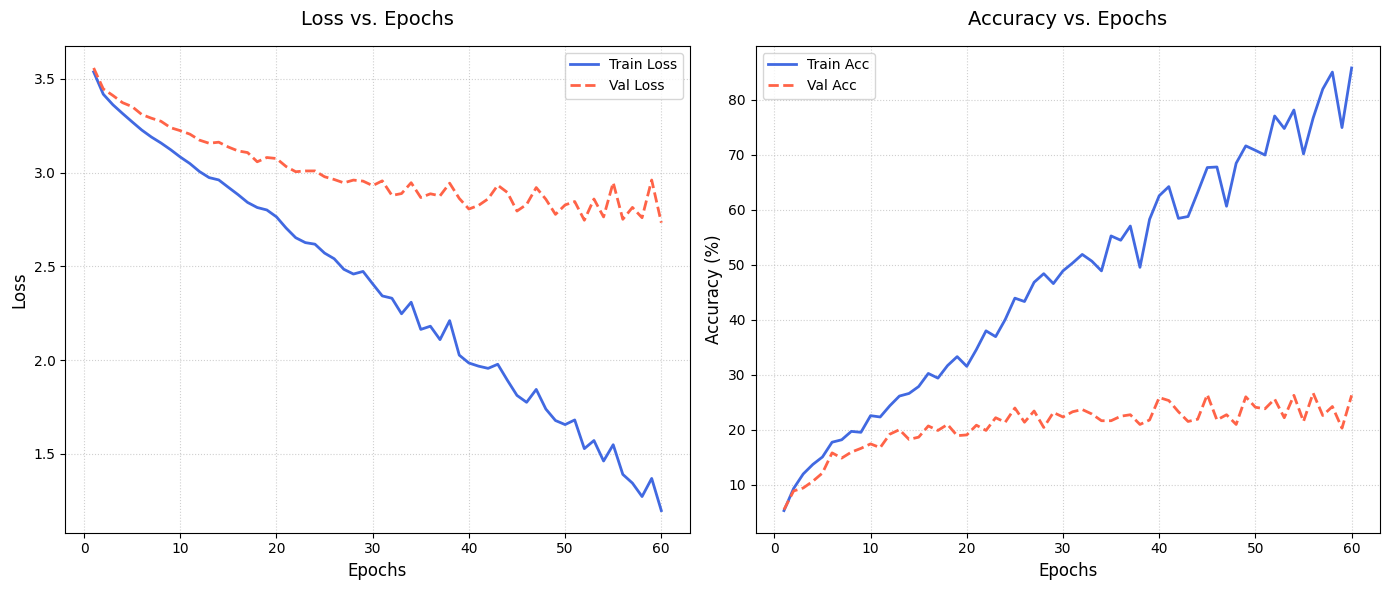

In [ ]:
plot_evaluation(epochs, optim_modifiedCNN6_hist)

### Resposta 7.4

Liste as modificações escolhidas e justifique em 1–2 linhas por que você decidiu testá-las.


## 8. Analise e discuta o efeito das mudanças

Com base nos experimentos da parte anterior:

**Tarefas**
1. Discuta quais mudanças ajudaram mais.
2. Discuta quais mudanças pouco ajudaram ou pioraram o resultado.
3. Comente possíveis razões para o comportamento observado.
4. Indique qual modelo/configuração você levará para a etapa final.

Use evidências das métricas e curvas.


### Resposta 8

Escreva sua análise aqui.


## 9. Treine usando uma ResNet pré-treinada

Agora use **transfer learning** com uma **ResNet pré-treinada**.

**Tarefas**
1. Carregue uma ResNet pré-treinada do `torchvision`.
2. Adapte a última camada para o número de classes.
3. Treine ao menos uma versão usando transfer learning.
4. Compare com sua melhor CNN da Parte 7.

**Sugestão.**
Você pode começar congelando a maior parte da rede e depois testar fine-tuning.


In [ ]:
# TODO:
# - carregar uma ResNet pré-treinada
# - adaptar a camada final
# - treinar
# - avaliar e comparar

# Dica:
# from torchvision.models import resnet18, ResNet18_Weights

# Escreva seu código aqui

from torchvision import models

# Arquitetura de resnet com os pesos treinados para o ImageNet
resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

for param in resnet.parameters():
    param.requires_grad = False

num_ftrs = resnet.fc.in_features

resnet.fc = nn.Sequential(
    nn.Linear(num_ftrs, 128),
    nn.BatchNorm1d(128),
    nn.ReLU(),
    
    nn.Dropout(0.5),
    nn.Linear(128, 37)
)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /impa/home/a/al.taina.drumond/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 85.9MB/s]


In [ ]:
resnet = resnet.to(device)
optimizer9 = optim.Adam(resnet.fc.parameters())

train_loss_hist9, train_accuracy_hist9, val_loss_hist9, val_accuracy_hist9 = \
fit(resnet, augmented_train_loader, val_loader, optimizer9, cross_entropy, device, epochs)

1/60 --- loss: 1.5542716098868328 | acc treino: 82.40489130434783 | acc val: 78.80434782608695
2/60 --- loss: 0.9311262939287268 | acc treino: 91.23641304347827 | acc val: 88.31521739130434
3/60 --- loss: 0.6176233071347942 | acc treino: 92.9008152173913 | acc val: 89.1304347826087
4/60 --- loss: 0.42725171926228894 | acc treino: 94.93885869565217 | acc val: 90.35326086956522
5/60 --- loss: 0.3282093836561493 | acc treino: 95.99184782608695 | acc val: 89.67391304347827
6/60 --- loss: 0.24426303415194803 | acc treino: 96.70516304347827 | acc val: 90.48913043478261
7/60 --- loss: 0.19868777821893277 | acc treino: 97.48641304347827 | acc val: 89.94565217391305
8/60 --- loss: 0.16116760800714078 | acc treino: 98.19972826086956 | acc val: 90.21739130434783
9/60 --- loss: 0.12851780831165935 | acc treino: 98.77717391304348 | acc val: 89.53804347826087
10/60 --- loss: 0.10920363130128902 | acc treino: 98.87907608695652 | acc val: 90.89673913043478
11/60 --- loss: 0.09184730360689371 | acc tre

### Resposta 9.4

Compare a ResNet com sua melhor CNN anterior. O ganho compensou?


## 10. Avaliações finais

Escolha seu melhor modelo final e faça uma avaliação mais detalhada.

**Tarefas**
1. Avalie no conjunto de teste.
2. Reporte:
   - loss;
   - acurácia;
   - matriz de confusão.
3. Mostre algumas imagens classificadas incorretamente.
4. Identifique pares de classes que geram mais confusão.
5. Discuta brevemente os principais erros do modelo.

**Observação.**
Use esta parte para mostrar que você inspecionou o comportamento do modelo além da acurácia final.


In [ ]:
# TODO:
# - avaliar no teste
# - calcular matriz de confusão
# - mostrar erros
# - discutir pares confusos

# Sugestão:
# use sklearn.metrics.confusion_matrix ou implementação própria

# Escreva seu código aqui


### Resposta 10.5

Discuta os erros mais importantes observados na avaliação final.


## 11. Bônus — Robustez

Faça um teste simples de robustez com o seu melhor modelo.

**Exemplos de variações possíveis**
- reduzir a resolução da imagem;
- adicionar ruído leve;
- mudar brilho/contraste;
- aplicar blur leve;
- testar imagens com crop diferente.

**Tarefas**
1. Escolha uma perturbação simples.
2. Compare o desempenho antes e depois.
3. Mostre alguns exemplos.
4. Comente o que isso sugere sobre a robustez do modelo.


In [ ]:
# TODO:
# - definir uma perturbação simples
# - reavaliar o melhor modelo
# - comparar métricas
# - mostrar exemplos

# Escreva seu código aqui

## Critérios de avaliação

A correção levará em conta:
- **implementação correta** dos componentes pedidos;
- **qualidade experimental** das comparações;
- **clareza da análise** dos resultados;
- **organização** do notebook;
- **coerência** entre conclusões e evidências.
